In [21]:
import gymnasium as gym
import numpy as np
import matplotlib.pyplot as plt

In [22]:
# -------------------------------------------------
# Create Environment
# -------------------------------------------------

env = gym.make("FrozenLake-v1", is_slippery=False)

n_states = env.observation_space.n
n_actions = env.action_space.n

print("Number of states:", n_states)
print("Number of actions:", n_actions)

Number of states: 16
Number of actions: 4


In [23]:

# -------------------------------------------------
# Hyperparameters
# -------------------------------------------------

num_episodes = 20000
gamma = 0.99
alpha = 0.1

epsilon_start = 1.0
epsilon_min = 0.05
epsilon_decay = 0.9995

max_steps_per_episode = 100



In [24]:
# -------------------------------------------------
# Initialize Q-table
# -------------------------------------------------

Q = np.zeros((n_states, n_actions))
episode_rewards = []


# -------------------------------------------------
# Epsilon-Greedy Action Selection
# -------------------------------------------------

# Write your code here

def epsilon_greedy_action(state, epsilon):
    """
    Selects an action using epsilon-greedy policy.
    """

    # Exploration
    if np.random.random() < epsilon:
        return env.action_space.sample()

    # Exploitation
    return np.argmax(Q[state])



In [25]:
# -------------------------------------------------
# Generate One Complete Episode
# -------------------------------------------------

def generate_episode(epsilon):
    """
    Generates one episode using the current epsilon-greedy policy.
    Returns a list of (state, action, reward).
    """

    episode = []

    state, info = env.reset()

    for _ in range(max_steps_per_episode):
        action = epsilon_greedy_action(state, epsilon)

        next_state, reward, terminated, truncated, info = env.step(action)

        episode.append((state, action, reward))

        state = next_state

        if terminated or truncated:
            break

    return episode



In [26]:
# -------------------------------------------------
# Monte Carlo Control
# -------------------------------------------------

epsilon = epsilon_start

for episode in range(num_episodes):

    # Generate a complete episode
    episode_data = generate_episode(epsilon)

    # Store total reward
    total_reward = sum(
        reward for state, action, reward in episode_data
    )

    episode_rewards.append(total_reward)

    # Calculate returns backwards
    G = 0.0

    for state, action, reward in reversed(episode_data):

        G = gamma * G + reward

        # Incremental Monte Carlo update
        Q[state, action] = Q[state, action] + \
            alpha * (G - Q[state, action])

    # Decay epsilon
    epsilon = max(
        epsilon_min,
        epsilon * epsilon_decay
    )

    # Display progress
    if (episode + 1) % 5000 == 0:
        avg_reward = np.mean(episode_rewards[-1000:])
        print(
            f"Episode {episode + 1}/{num_episodes}, "
            f"Epsilon: {epsilon:.4f}, "
            f"Average Reward: {avg_reward:.3f}"
        )

Episode 5000/20000, Epsilon: 0.0820, Average Reward: 0.871
Episode 10000/20000, Epsilon: 0.0500, Average Reward: 0.940
Episode 15000/20000, Epsilon: 0.0500, Average Reward: 0.949
Episode 20000/20000, Epsilon: 0.0500, Average Reward: 0.948


In [27]:
# -------------------------------------------------
# Extract Greedy Policy
# -------------------------------------------------

optimal_policy = np.argmax(Q, axis=1)
state_values = np.max(Q, axis=1)


In [28]:
# -------------------------------------------------
# Display Results
# -------------------------------------------------

def print_policy(policy):
    action_symbols = {
        0: "L",
        1: "D",
        2: "R",
        3: "U"
    }

    policy_grid = np.array(
        [action_symbols[action] for action in policy]
    ).reshape(4, 4)
    print("Name: Loknaath P")
    print("Register Number: 212223240080")
    print("\nLearned Policy:")
    print(policy_grid)


def print_value_function(values):
    print("\nEstimated State-Value Function:")
    print(np.round(values.reshape(4, 4), 3))


print("\nFinal Q-table:")
print(np.round(Q, 3))

print_value_function(state_values)
print_policy(optimal_policy)

success_rate = np.mean(episode_rewards[-1000:])
print("\nAverage reward over last 1000 episodes:", success_rate)




Final Q-table:
[[0.701 0.949 0.718 0.691]
 [0.002 0.    0.765 0.01 ]
 [0.019 0.81  0.032 0.107]
 [0.036 0.    0.    0.079]
 [0.777 0.959 0.    0.744]
 [0.    0.    0.    0.   ]
 [0.    0.96  0.    0.133]
 [0.    0.    0.    0.   ]
 [0.78  0.    0.969 0.705]
 [0.801 0.845 0.98  0.   ]
 [0.776 0.99  0.    0.936]
 [0.    0.    0.    0.   ]
 [0.    0.    0.    0.   ]
 [0.    0.953 0.99  0.93 ]
 [0.978 0.989 1.    0.979]
 [0.    0.    0.    0.   ]]

Estimated State-Value Function:
[[0.949 0.765 0.81  0.079]
 [0.959 0.    0.96  0.   ]
 [0.969 0.98  0.99  0.   ]
 [0.    0.99  1.    0.   ]]
Name: Loknaath P
Register Number: 212223240080

Learned Policy:
[['D' 'R' 'D' 'U']
 ['D' 'L' 'D' 'L']
 ['R' 'R' 'D' 'L']
 ['L' 'R' 'R' 'L']]

Average reward over last 1000 episodes: 0.948


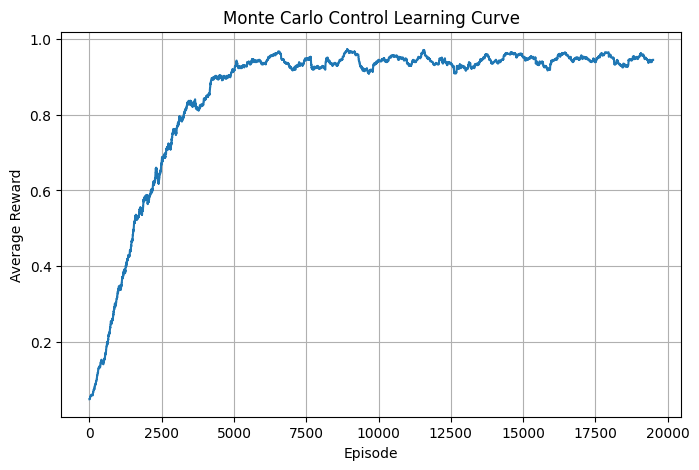

In [29]:
# -------------------------------------------------
# Plot Learning Curve
# -------------------------------------------------

window = 500
moving_average = np.convolve(
    episode_rewards,
    np.ones(window) / window,
    mode="valid"
)

plt.figure(figsize=(8, 5))
plt.plot(moving_average)
plt.xlabel("Episode")
plt.ylabel("Average Reward")
plt.title("Monte Carlo Control Learning Curve")
plt.grid(True)
plt.show()

env.close()